# Classical vs Quantum Machine Learning on Small Datasets

## Project Overview

In this project, I compare a few classical machine learning models with a small quantum machine learning model and check how their results change with different training sizes.

A breast cancer classification dataset from scikit-learn is used for the experiment. Classical models are first trained using the original feature set. For the quantum machine learning experiment, Principal Component Analysis (PCA) is used to reduce the data to two features, which are then encoded into a 2-qubit quantum circuit.

### Research Question

**How do classical and quantum machine learning methods compare when training on small datasets?**

### Objective

To compare classical machine learning models with a quantum machine learning approach on a small classification dataset and examine how the observed VQC performance changes with different training dataset sizes.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

In [ ]:
# Load the dataset
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])
print("Classes:", data.target_names)

Number of samples: 569
Number of features: 30
Classes: ['malignant' 'benign']


In [ ]:
# Display the first 5 rows
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
# Check how many samples belong to each class
y.value_counts()

,count
target,
1,357
0,212


In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])

Training set size: 455
Testing set size: 114


In [ ]:
from sklearn.preprocessing import StandardScaler

# Create the scaler
scaler = StandardScaler()

# Fit the scaler only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Use the same scaling on test data
X_test_scaled = scaler.transform(X_test)

print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

Training data shape: (455, 30)
Testing data shape: (114, 30)


In [ ]:
from sklearn.linear_model import LogisticRegression

# Create the model
logistic_model = LogisticRegression(max_iter=1000)

# Train the model
logistic_model.fit(X_train_scaled, y_train)

# Make predictions on the test data
y_pred_logistic = logistic_model.predict(X_test_scaled)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [ ]:
from sklearn.metrics import accuracy_score, f1_score

# Calculate evaluation metrics
accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
f1_logistic = f1_score(y_test, y_pred_logistic)

print("Logistic Regression Accuracy:", accuracy_logistic)
print("Logistic Regression F1 Score:", f1_logistic)

Logistic Regression Accuracy: 0.9824561403508771
Logistic Regression F1 Score: 0.9861111111111112


## Logistic Regression Results

Logistic Regression was used as the first baseline model. The model was trained on the training set and evaluated on the unseen test set using accuracy and F1 score.

In [ ]:
from sklearn.svm import SVC

# Create the SVM model
svm_model = SVC()

# Train the model
svm_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_svm = svm_model.predict(X_test_scaled)

print("SVM model trained successfully.")

SVM model trained successfully.


In [ ]:
from sklearn.metrics import accuracy_score, f1_score

# Calculate evaluation metrics
accuracy_svm = accuracy_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

print("SVM Accuracy:", accuracy_svm)
print("SVM F1 Score:", f1_svm)

SVM Accuracy: 0.9824561403508771
SVM F1 Score: 0.9861111111111112


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest model
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
random_forest_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = random_forest_model.predict(X_test)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [ ]:
from sklearn.metrics import accuracy_score, f1_score

# Calculate evaluation metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)
print("Random Forest F1 Score:", f1_rf)

Random Forest Accuracy: 0.956140350877193
Random Forest F1 Score: 0.9655172413793104


## Classical Machine Learning Results

The three classical machine learning models were tested using the same test set and evaluation metrics. Logistic Regression and SVM gave the same results in this experiment, while Random Forest had slightly lower scores.

| Model | Accuracy | F1 Score |
|---|---:|---:|
| Logistic Regression | 98.25% | 98.61% |
| SVM | 98.25% | 98.61% |
| Random Forest | 95.61% | 96.55% |

These results are based on a single train-test split and should not be treated as a general comparison of the models.

## Effect of Training Dataset Size

To study how the amount of training data affects model performance, the classical machine learning models will be trained using different proportions of the training dataset.

The experiments will use 20%, 40%, 60%, and 80% of the training data while keeping the test set fixed.

This allows us to observe how model performance changes as the amount of available training data increases.

In [ ]:
# Training data proportions we want to test
training_sizes = [0.2, 0.4, 0.6, 0.8]

print("Training sizes:", training_sizes)

Training sizes: [0.2, 0.4, 0.6, 0.8]


In [ ]:
# Store the number of training samples
total_training_samples = len(X_train_scaled)

print("Total training samples:", total_training_samples)

Total training samples: 455


In [ ]:
# Calculate the number of samples for each training size
sample_counts = [int(total_training_samples * size) for size in training_sizes]

print("Number of samples for each training size:", sample_counts)

Number of samples for each training size: [91, 182, 273, 364]


In [ ]:
# Select the first 20% of the training data
X_train_20 = X_train_scaled[:sample_counts[0]]
y_train_20 = y_train.iloc[:sample_counts[0]]

print("20% training data shape:", X_train_20.shape)
print("20% training labels:", y_train_20.shape)

20% training data shape: (91, 30)
20% training labels: (91,)


In [ ]:
# Create a Logistic Regression model for the 20% dataset
logistic_20 = LogisticRegression(max_iter=1000)

# Train the model using the 20% training data
logistic_20.fit(X_train_20, y_train_20)

# Make predictions on the same fixed test set
y_pred_logistic_20 = logistic_20.predict(X_test_scaled)

print("Logistic Regression trained using 20% of the training data.")

Logistic Regression trained using 20% of the training data.


In [ ]:
# Calculate performance of the 20% Logistic Regression model
accuracy_logistic_20 = accuracy_score(y_test, y_pred_logistic_20)
f1_logistic_20 = f1_score(y_test, y_pred_logistic_20)

print("20% Training Data")
print("Accuracy:", accuracy_logistic_20)
print("F1 Score:", f1_logistic_20)

20% Training Data
Accuracy: 0.9649122807017544
F1 Score: 0.971830985915493


In [ ]:
# Store the 20% Logistic Regression result
logistic_results = []

logistic_results.append({
    "Training Size": 20,
    "Accuracy": accuracy_logistic_20,
    "F1 Score": f1_logistic_20
})

print(logistic_results)

[{'Training Size': 20, 'Accuracy': 0.9649122807017544, 'F1 Score': 0.971830985915493}]


In [ ]:
# Select the first 40% of the training data
X_train_40 = X_train_scaled[:sample_counts[1]]
y_train_40 = y_train.iloc[:sample_counts[1]]

print("40% training data shape:", X_train_40.shape)
print("40% training labels:", y_train_40.shape)

40% training data shape: (182, 30)
40% training labels: (182,)


In [ ]:
# Create a Logistic Regression model for the 40% dataset
logistic_40 = LogisticRegression(max_iter=1000)

# Train the model using the 40% training data
logistic_40.fit(X_train_40, y_train_40)

# Make predictions on the same fixed test set
y_pred_logistic_40 = logistic_40.predict(X_test_scaled)

print("Logistic Regression trained using 40% of the training data.")

Logistic Regression trained using 40% of the training data.


In [ ]:
# Calculate performance of the 40% Logistic Regression model
accuracy_logistic_40 = accuracy_score(y_test, y_pred_logistic_40)
f1_logistic_40 = f1_score(y_test, y_pred_logistic_40)

print("40% Training Data")
print("Accuracy:", accuracy_logistic_40)
print("F1 Score:", f1_logistic_40)

40% Training Data
Accuracy: 0.9824561403508771
F1 Score: 0.9861111111111112


In [ ]:
# Store the 40% Logistic Regression result
logistic_results.append({
    "Training Size": 40,
    "Accuracy": accuracy_logistic_40,
    "F1 Score": f1_logistic_40
})

print(logistic_results)

[{'Training Size': 20, 'Accuracy': 0.9649122807017544, 'F1 Score': 0.971830985915493}, {'Training Size': 40, 'Accuracy': 0.9824561403508771, 'F1 Score': 0.9861111111111112}]


In [ ]:
# Select the first 60% of the training data
X_train_60 = X_train_scaled[:sample_counts[2]]
y_train_60 = y_train.iloc[:sample_counts[2]]

print("60% training data shape:", X_train_60.shape)
print("60% training labels:", y_train_60.shape)

60% training data shape: (273, 30)
60% training labels: (273,)


In [ ]:
# Create a Logistic Regression model for the 60% dataset
logistic_60 = LogisticRegression(max_iter=1000)

# Train the model using the 60% training data
logistic_60.fit(X_train_60, y_train_60)

# Make predictions on the same fixed test set
y_pred_logistic_60 = logistic_60.predict(X_test_scaled)

print("Logistic Regression trained using 60% of the training data.")

Logistic Regression trained using 60% of the training data.


In [ ]:
# Calculate performance of the 60% Logistic Regression model
accuracy_logistic_60 = accuracy_score(y_test, y_pred_logistic_60)
f1_logistic_60 = f1_score(y_test, y_pred_logistic_60)

print("60% Training Data")
print("Accuracy:", accuracy_logistic_60)
print("F1 Score:", f1_logistic_60)

60% Training Data
Accuracy: 0.9824561403508771
F1 Score: 0.9861111111111112


In [ ]:
# Store the 60% Logistic Regression result
logistic_results.append({
    "Training Size": 60,
    "Accuracy": accuracy_logistic_60,
    "F1 Score": f1_logistic_60
})

print(logistic_results)

[{'Training Size': 20, 'Accuracy': 0.9649122807017544, 'F1 Score': 0.971830985915493}, {'Training Size': 40, 'Accuracy': 0.9824561403508771, 'F1 Score': 0.9861111111111112}, {'Training Size': 60, 'Accuracy': 0.9824561403508771, 'F1 Score': 0.9861111111111112}]


In [ ]:
# Select the first 80% of the training data
X_train_80 = X_train_scaled[:sample_counts[3]]
y_train_80 = y_train.iloc[:sample_counts[3]]

print("80% training data shape:", X_train_80.shape)
print("80% training labels:", y_train_80.shape)

80% training data shape: (364, 30)
80% training labels: (364,)


In [ ]:
# Create a Logistic Regression model for the 80% dataset
logistic_80 = LogisticRegression(max_iter=1000)

# Train the model using the 80% training data
logistic_80.fit(X_train_80, y_train_80)

# Make predictions on the same fixed test set
y_pred_logistic_80 = logistic_80.predict(X_test_scaled)

print("Logistic Regression trained using 80% of the training data.")

Logistic Regression trained using 80% of the training data.


In [ ]:
# Calculate performance of the 80% Logistic Regression model
accuracy_logistic_80 = accuracy_score(y_test, y_pred_logistic_80)
f1_logistic_80 = f1_score(y_test, y_pred_logistic_80)

print("80% Training Data")
print("Accuracy:", accuracy_logistic_80)
print("F1 Score:", f1_logistic_80)

80% Training Data
Accuracy: 0.9824561403508771
F1 Score: 0.9861111111111112


In [ ]:
# Store the 80% Logistic Regression result
logistic_results.append({
    "Training Size": 80,
    "Accuracy": accuracy_logistic_80,
    "F1 Score": f1_logistic_80
})

print(logistic_results)

[{'Training Size': 20, 'Accuracy': 0.9649122807017544, 'F1 Score': 0.971830985915493}, {'Training Size': 40, 'Accuracy': 0.9824561403508771, 'F1 Score': 0.9861111111111112}, {'Training Size': 60, 'Accuracy': 0.9824561403508771, 'F1 Score': 0.9861111111111112}, {'Training Size': 80, 'Accuracy': 0.9824561403508771, 'F1 Score': 0.9861111111111112}]


In [ ]:
# Convert the Logistic Regression results into a table
logistic_results_df = pd.DataFrame(logistic_results)

print(logistic_results_df)

   Training Size  Accuracy  F1 Score
0             20  0.964912  0.971831
1             40  0.982456  0.986111
2             60  0.982456  0.986111
3             80  0.982456  0.986111


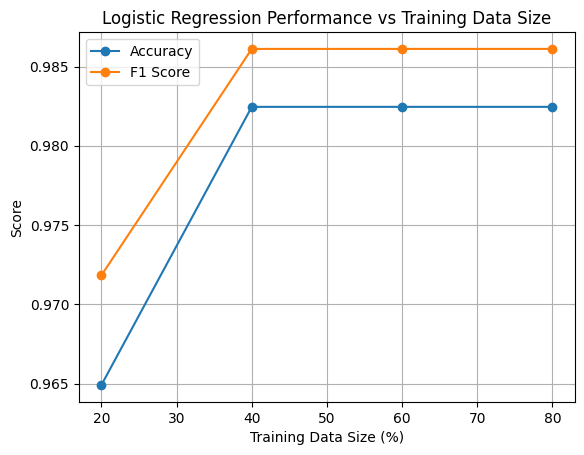

In [ ]:
# Plot Logistic Regression performance for different training sizes
plt.plot(
    logistic_results_df["Training Size"],
    logistic_results_df["Accuracy"],
    marker="o",
    label="Accuracy"
)

plt.plot(
    logistic_results_df["Training Size"],
    logistic_results_df["F1 Score"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Training Data Size (%)")
plt.ylabel("Score")
plt.title("Logistic Regression Performance vs Training Data Size")
plt.legend()
plt.grid(True)

plt.show()

## Observation: Logistic Regression and Training Data Size

In this experiment, Logistic Regression showed lower performance when trained on 20% of the available training data. The accuracy and F1 score increased when the training size was increased to 40%.

The scores remained the same at 60% and 80% training sizes for this particular train-test split. This suggests that, in this experiment, increasing the training data beyond 40% did not produce an additional improvement in the test-set scores.

These observations are specific to the dataset, train-test split, and model settings used in this experiment and should not be generalized to other datasets.

In [ ]:
# Create an empty list to store SVM results
svm_results = []

print("SVM results list created.")

SVM results list created.


In [ ]:
# Create an SVM model for the 20% dataset
svm_20 = SVC()

# Train the model using the 20% training data
svm_20.fit(X_train_20, y_train_20)

# Make predictions on the same fixed test set
y_pred_svm_20 = svm_20.predict(X_test_scaled)

print("SVM trained using 20% of the training data.")

SVM trained using 20% of the training data.


In [ ]:
# Calculate performance of the 20% SVM model
accuracy_svm_20 = accuracy_score(y_test, y_pred_svm_20)
f1_svm_20 = f1_score(y_test, y_pred_svm_20)

print("20% Training Data")
print("Accuracy:", accuracy_svm_20)
print("F1 Score:", f1_svm_20)

20% Training Data
Accuracy: 0.9649122807017544
F1 Score: 0.9726027397260274


In [ ]:
# Store the 20% SVM result
svm_results.append({
    "Training Size": 20,
    "Accuracy": accuracy_svm_20,
    "F1 Score": f1_svm_20
})

print(svm_results)

[{'Training Size': 20, 'Accuracy': 0.9649122807017544, 'F1 Score': 0.9726027397260274}]


In [ ]:
# Create an SVM model for the 40% dataset
svm_40 = SVC()

# Train the model using the 40% training data
svm_40.fit(X_train_40, y_train_40)

# Make predictions on the same fixed test set
y_pred_svm_40 = svm_40.predict(X_test_scaled)

print("SVM trained using 40% of the training data.")

SVM trained using 40% of the training data.


In [ ]:
# Calculate performance of the 40% SVM model
accuracy_svm_40 = accuracy_score(y_test, y_pred_svm_40)
f1_svm_40 = f1_score(y_test, y_pred_svm_40)

print("40% Training Data")
print("Accuracy:", accuracy_svm_40)
print("F1 Score:", f1_svm_40)

40% Training Data
Accuracy: 0.9736842105263158
F1 Score: 0.9795918367346939


In [ ]:
# Store the 40% SVM result
svm_results.append({
    "Training Size": 40,
    "Accuracy": accuracy_svm_40,
    "F1 Score": f1_svm_40
})

print(svm_results)

[{'Training Size': 20, 'Accuracy': 0.9649122807017544, 'F1 Score': 0.9726027397260274}, {'Training Size': 40, 'Accuracy': 0.9736842105263158, 'F1 Score': 0.9795918367346939}]


In [ ]:
# Create an SVM model for the 60% dataset
svm_60 = SVC()

# Train the model using the 60% training data
svm_60.fit(X_train_60, y_train_60)

# Make predictions on the same fixed test set
y_pred_svm_60 = svm_60.predict(X_test_scaled)

print("SVM trained using 60% of the training data.")

SVM trained using 60% of the training data.


In [ ]:
# Calculate performance of the 60% SVM model
accuracy_svm_60 = accuracy_score(y_test, y_pred_svm_60)
f1_svm_60 = f1_score(y_test, y_pred_svm_60)

print("60% Training Data")
print("Accuracy:", accuracy_svm_60)
print("F1 Score:", f1_svm_60)

60% Training Data
Accuracy: 0.9824561403508771
F1 Score: 0.9863013698630136


In [ ]:
# Store the 60% SVM result
svm_results.append({
    "Training Size": 60,
    "Accuracy": accuracy_svm_60,
    "F1 Score": f1_svm_60
})

print(svm_results)

[{'Training Size': 20, 'Accuracy': 0.9649122807017544, 'F1 Score': 0.9726027397260274}, {'Training Size': 40, 'Accuracy': 0.9736842105263158, 'F1 Score': 0.9795918367346939}, {'Training Size': 60, 'Accuracy': 0.9824561403508771, 'F1 Score': 0.9863013698630136}]


In [ ]:
# Create an SVM model for the 80% dataset
svm_80 = SVC()

# Train the model using the 80% training data
svm_80.fit(X_train_80, y_train_80)

# Make predictions on the same fixed test set
y_pred_svm_80 = svm_80.predict(X_test_scaled)

print("SVM trained using 80% of the training data.")

SVM trained using 80% of the training data.


In [ ]:
# Calculate performance of the 80% SVM model
accuracy_svm_80 = accuracy_score(y_test, y_pred_svm_80)
f1_svm_80 = f1_score(y_test, y_pred_svm_80)

print("80% Training Data")
print("Accuracy:", accuracy_svm_80)
print("F1 Score:", f1_svm_80)

80% Training Data
Accuracy: 0.9649122807017544
F1 Score: 0.9722222222222222


In [ ]:
# Store the 80% SVM result
svm_results.append({
    "Training Size": 80,
    "Accuracy": accuracy_svm_80,
    "F1 Score": f1_svm_80
})

print(svm_results)

[{'Training Size': 20, 'Accuracy': 0.9649122807017544, 'F1 Score': 0.9726027397260274}, {'Training Size': 40, 'Accuracy': 0.9736842105263158, 'F1 Score': 0.9795918367346939}, {'Training Size': 60, 'Accuracy': 0.9824561403508771, 'F1 Score': 0.9863013698630136}, {'Training Size': 80, 'Accuracy': 0.9649122807017544, 'F1 Score': 0.9722222222222222}]


In [ ]:
# Convert the SVM results into a table
svm_results_df = pd.DataFrame(svm_results)

print(svm_results_df)

   Training Size  Accuracy  F1 Score
0             20  0.964912  0.972603
1             40  0.973684  0.979592
2             60  0.982456  0.986301
3             80  0.964912  0.972222


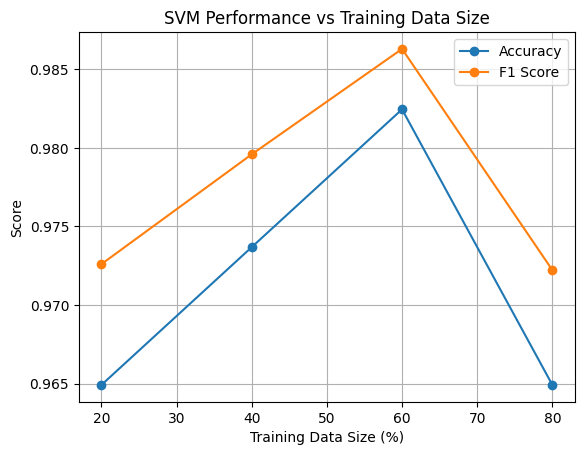

In [ ]:
# Plot SVM performance for different training sizes
plt.plot(
    svm_results_df["Training Size"],
    svm_results_df["Accuracy"],
    marker="o",
    label="Accuracy"
)

plt.plot(
    svm_results_df["Training Size"],
    svm_results_df["F1 Score"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Training Data Size (%)")
plt.ylabel("Score")
plt.title("SVM Performance vs Training Data Size")
plt.legend()
plt.grid(True)

plt.show()

## Observation: SVM and Training Data Size

In this experiment, SVM performance increased as the training size was increased from 20% to 60%. The highest test-set accuracy and F1 score were observed at 60% training data.

When the training size was increased to 80%, both scores decreased compared with the 60% experiment. This shows that the relationship between training data size and test-set performance was not strictly increasing for SVM in this particular experiment.

These observations are specific to the dataset, train-test split, and model settings used here and should not be generalized to other datasets.

In [ ]:
# Create an empty list to store Random Forest results
rf_results = []

print("Random Forest results list created.")

Random Forest results list created.


In [434]:
# Create a Random Forest model for the 20% dataset
rf_20 = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model using the 20% training data
rf_20.fit(X_train_20, y_train_20)

# Make predictions on the same fixed test set
y_pred_rf_20 = rf_20.predict(X_test_scaled)

print("Random Forest trained using 20% of the training data.")

Random Forest trained using 20% of the training data.


In [435]:
# Calculate performance of the 20% Random Forest model
accuracy_rf_20 = accuracy_score(y_test, y_pred_rf_20)
f1_rf_20 = f1_score(y_test, y_pred_rf_20)

print("20% Training Data")
print("Accuracy:", accuracy_rf_20)
print("F1 Score:", f1_rf_20)

20% Training Data
Accuracy: 0.9385964912280702
F1 Score: 0.951048951048951


In [430]:
# Store the 20% Random Forest result
rf_results.append({
    "Training Size": 20,
    "Accuracy": accuracy_rf_20,
    "F1 Score": f1_rf_20
})

print(rf_results)

[{'Training Size': 20, 'Accuracy': 0.9385964912280702, 'F1 Score': 0.951048951048951}, {'Training Size': 40, 'Accuracy': 0.9473684210526315, 'F1 Score': 0.9583333333333334}, {'Training Size': 60, 'Accuracy': 0.956140350877193, 'F1 Score': 0.9655172413793104}, {'Training Size': 80, 'Accuracy': 0.9385964912280702, 'F1 Score': 0.951048951048951}, {'Training Size': 60, 'Accuracy': 0.3684210526315789, 'F1 Score': 0.0}, {'Training Size': 40, 'Accuracy': 0.3684210526315789, 'F1 Score': 0.0}, {'Training Size': 20, 'Accuracy': 0.3684210526315789, 'F1 Score': 0.0}, {'Training Size': 20, 'Accuracy': 0.3684210526315789, 'F1 Score': 0.0}]


In [436]:
# Create a Random Forest model for the 40% dataset
rf_40 = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model using the 40% training data
rf_40.fit(X_train_40, y_train_40)

# Make predictions on the same fixed test set
y_pred_rf_40 = rf_40.predict(X_test_scaled)

print("Random Forest trained using 40% of the training data.")

Random Forest trained using 40% of the training data.


In [437]:
# Calculate performance of the 40% Random Forest model
accuracy_rf_40 = accuracy_score(y_test, y_pred_rf_40)
f1_rf_40 = f1_score(y_test, y_pred_rf_40)

print("40% Training Data")
print("Accuracy:", accuracy_rf_40)
print("F1 Score:", f1_rf_40)

40% Training Data
Accuracy: 0.9473684210526315
F1 Score: 0.9583333333333334


In [428]:
# Store the 40% Random Forest result
rf_results.append({
    "Training Size": 40,
    "Accuracy": accuracy_rf_40,
    "F1 Score": f1_rf_40
})

print(rf_results)

[{'Training Size': 20, 'Accuracy': 0.9385964912280702, 'F1 Score': 0.951048951048951}, {'Training Size': 40, 'Accuracy': 0.9473684210526315, 'F1 Score': 0.9583333333333334}, {'Training Size': 60, 'Accuracy': 0.956140350877193, 'F1 Score': 0.9655172413793104}, {'Training Size': 80, 'Accuracy': 0.9385964912280702, 'F1 Score': 0.951048951048951}, {'Training Size': 60, 'Accuracy': 0.3684210526315789, 'F1 Score': 0.0}, {'Training Size': 40, 'Accuracy': 0.3684210526315789, 'F1 Score': 0.0}]


In [438]:
# Create a Random Forest model for the 60% dataset
rf_60 = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model using the 60% training data
rf_60.fit(X_train_60, y_train_60)

# Make predictions on the same fixed test set
y_pred_rf_60 = rf_60.predict(X_test_scaled)

print("Random Forest trained using 60% of the training data.")

Random Forest trained using 60% of the training data.


In [439]:
# Calculate performance of the 60% Random Forest model
accuracy_rf_60 = accuracy_score(y_test, y_pred_rf_60)
f1_rf_60 = f1_score(y_test, y_pred_rf_60)

print("60% Training Data")
print("Accuracy:", accuracy_rf_60)
print("F1 Score:", f1_rf_60)

60% Training Data
Accuracy: 0.956140350877193
F1 Score: 0.9655172413793104


In [427]:
# Store the 60% Random Forest result
rf_results.append({
    "Training Size": 60,
    "Accuracy": accuracy_rf_60,
    "F1 Score": f1_rf_60
})

print(rf_results)

[{'Training Size': 20, 'Accuracy': 0.9385964912280702, 'F1 Score': 0.951048951048951}, {'Training Size': 40, 'Accuracy': 0.9473684210526315, 'F1 Score': 0.9583333333333334}, {'Training Size': 60, 'Accuracy': 0.956140350877193, 'F1 Score': 0.9655172413793104}, {'Training Size': 80, 'Accuracy': 0.9385964912280702, 'F1 Score': 0.951048951048951}, {'Training Size': 60, 'Accuracy': 0.3684210526315789, 'F1 Score': 0.0}]


In [440]:
# Create a Random Forest model for the 80% dataset
rf_80 = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model using the 80% training data
rf_80.fit(X_train_80, y_train_80)

# Make predictions on the same fixed test set
y_pred_rf_80 = rf_80.predict(X_test_scaled)

print("Random Forest trained using 80% of the training data.")

Random Forest trained using 80% of the training data.


In [441]:
# Calculate performance of the 80% Random Forest model
accuracy_rf_80 = accuracy_score(y_test, y_pred_rf_80)
f1_rf_80 = f1_score(y_test, y_pred_rf_80)

print("80% Training Data")
print("Accuracy:", accuracy_rf_80)
print("F1 Score:", f1_rf_80)

80% Training Data
Accuracy: 0.9385964912280702
F1 Score: 0.951048951048951


In [ ]:
# Store the 80% Random Forest result
rf_results.append({
    "Training Size": 80,
    "Accuracy": accuracy_rf_80,
    "F1 Score": f1_rf_80
})

print(rf_results)

[{'Training Size': 20, 'Accuracy': 0.9385964912280702, 'F1 Score': 0.951048951048951}, {'Training Size': 40, 'Accuracy': 0.9473684210526315, 'F1 Score': 0.9583333333333334}, {'Training Size': 60, 'Accuracy': 0.956140350877193, 'F1 Score': 0.9655172413793104}, {'Training Size': 80, 'Accuracy': 0.9385964912280702, 'F1 Score': 0.951048951048951}]


In [ ]:
# Convert the Random Forest results into a table
rf_results_df = pd.DataFrame(rf_results)

print(rf_results_df)

   Training Size  Accuracy  F1 Score
0             20  0.938596  0.951049
1             40  0.947368  0.958333
2             60  0.956140  0.965517
3             80  0.938596  0.951049


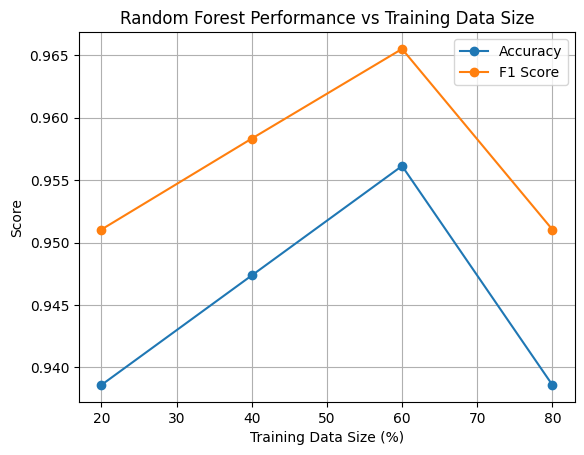

In [ ]:
# Plot Random Forest performance for different training sizes
plt.plot(
    rf_results_df["Training Size"],
    rf_results_df["Accuracy"],
    marker="o",
    label="Accuracy"
)

plt.plot(
    rf_results_df["Training Size"],
    rf_results_df["F1 Score"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Training Data Size (%)")
plt.ylabel("Score")
plt.title("Random Forest Performance vs Training Data Size")
plt.legend()
plt.grid(True)

plt.show()

## Observation: Random Forest and Training Data Size

In this experiment, Random Forest performance increased from 20% to 60% training data. The highest accuracy and F1 score were observed at 60% training data.

At 80% training data, both scores decreased compared with the 60% experiment. Therefore, the test-set performance did not increase continuously with the amount of training data in this experiment.

These observations are specific to the dataset, train-test split, and model settings used here and should not be generalized to other datasets.

## Preparing Data for Quantum Machine Learning

The original dataset contains 30 features. Since the quantum model will use a small number of qubits, the feature space is reduced to two dimensions using Principal Component Analysis (PCA).

The two resulting components will be used as inputs to the quantum circuit.

In [ ]:
from sklearn.decomposition import PCA

# Create a PCA model that keeps 2 components
pca = PCA(n_components=2)

# Fit PCA only on the training data
X_train_pca = pca.fit_transform(X_train_scaled)

# Apply the same PCA transformation to the test data
X_test_pca = pca.transform(X_test_scaled)

print("Original number of features:", X_train_scaled.shape[1])
print("Number of features after PCA:", X_train_pca.shape[1])

Original number of features: 30
Number of features after PCA: 2


In [ ]:
# Check how much variance is retained by the two PCA components
explained_variance = pca.explained_variance_ratio_

print("Variance explained by Component 1:", explained_variance[0])
print("Variance explained by Component 2:", explained_variance[1])
print("Total variance explained:", explained_variance.sum())

Variance explained by Component 1: 0.4441349175612421
Variance explained by Component 2: 0.18944618311600697
Total variance explained: 0.6335811006772492


The two PCA components explain about 63.36% of the variance in the training data. These two components are used as the input features for the quantum model.

In [ ]:
# Check the shape of the PCA-reduced data
print("PCA training data shape:", X_train_pca.shape)
print("PCA test data shape:", X_test_pca.shape)

PCA training data shape: (455, 2)
PCA test data shape: (114, 2)


In [ ]:
!pip install qiskit qiskit-machine-learning

## Quantum Feature Map

The two PCA features are used as inputs to the quantum circuit. A quantum feature map encodes these classical values into the quantum state of the qubits.

Here, a two-qubit ZZ feature map is used to encode the two PCA features.

In [ ]:
from qiskit.circuit.library import zz_feature_map

feature_map = zz_feature_map(
    feature_dimension=2,
    reps=1
)

print(feature_map)

   ┌───┐┌───────────┐                                          
0: ┤ H ├┤ P(2*x[0]) ├──■────────────────────────────────────■──
   ├───┤├───────────┤┌─┴─┐┌──────────────────────────────┐┌─┴─┐
1: ┤ H ├┤ P(2*x[1]) ├┤ X ├┤ P((-π + x[0])*(-π + x[1])*2) ├┤ X ├
   └───┘└───────────┘└───┘└──────────────────────────────┘└───┘


## Quantum Ansatz

The ansatz is the trainable part of the quantum circuit. It contains parameterized rotation gates and entangling gates between the qubits.

The parameters of the ansatz are adjusted during training so that the circuit can learn from the input data.

In [ ]:
from qiskit.circuit.library import real_amplitudes

ansatz = real_amplitudes(
    num_qubits=2,
    reps=1
)

print(ansatz)

     ┌──────────┐     ┌──────────┐
q_0: ┤ Ry(θ[0]) ├──■──┤ Ry(θ[2]) ├
     ├──────────┤┌─┴─┐├──────────┤
q_1: ┤ Ry(θ[1]) ├┤ X ├┤ Ry(θ[3]) ├
     └──────────┘└───┘└──────────┘


In [ ]:
from qiskit_machine_learning.optimizers import COBYLA

optimizer = COBYLA(maxiter=30)

print("Optimizer:", optimizer)

Optimizer: <qiskit_machine_learning.optimizers.cobyla.COBYLA object at 0x790b1a3ead70>


## Variational Quantum Classifier

The quantum feature map and ansatz are combined to create a Variational Quantum Classifier (VQC).

The VQC uses a classical optimizer to adjust the trainable parameters of the quantum circuit during training.

In [ ]:
vqc = VQC(
    feature_map=feature_map,
    ansatz=ansatz,
    optimizer=optimizer
)

print("Quantum classifier created successfully.")

Quantum classifier created successfully.


In [ ]:
X_train_pca_20 = X_train_pca[:sample_counts[0]]
y_train_pca_20 = y_train.iloc[:sample_counts[0]].to_numpy()

print("Training samples:", len(X_train_pca_20))
print("Number of features:", X_train_pca_20.shape[1])

Training samples: 91
Number of features: 2


In [ ]:
vqc.fit(X_train_pca_20, y_train_pca_20)

print("VQC training completed.")

VQC training completed.


In [ ]:
y_pred_vqc_20 = vqc.predict(X_test_pca)

print("Predictions completed.")
print("Number of predictions:", len(y_pred_vqc_20))

Predictions completed.
Number of predictions: 114


In [ ]:
from sklearn.metrics import accuracy_score, f1_score

accuracy_vqc_20 = accuracy_score(y_test, y_pred_vqc_20)
f1_vqc_20 = f1_score(y_test, y_pred_vqc_20)

print("VQC Accuracy:", accuracy_vqc_20)
print("VQC F1-score:", f1_vqc_20)

VQC Accuracy: 0.5350877192982456
VQC F1-score: 0.5891472868217055


In [ ]:
vqc_results = []

vqc_results.append({
    "Training Size": 20,
    "Accuracy": accuracy_vqc_20,
    "F1 Score": f1_vqc_20
})

print(vqc_results)

[{'Training Size': 20, 'Accuracy': 0.5350877192982456, 'F1 Score': 0.5891472868217055}]


In [ ]:
X_train_pca_40 = X_train_pca[:sample_counts[1]]
y_train_pca_40 = y_train.iloc[:sample_counts[1]].to_numpy()

print("Training samples:", len(X_train_pca_40))
print("Number of features:", X_train_pca_40.shape[1])

Training samples: 182
Number of features: 2


In [ ]:
vqc.fit(X_train_pca_40, y_train_pca_40)

print("VQC training completed for 40% data.")

VQC training completed for 40% data.


In [ ]:
y_pred_vqc_40 = vqc.predict(X_test_pca)

print("Predictions completed.")
print("Number of predictions:", len(y_pred_vqc_40))

Predictions completed.
Number of predictions: 114


In [ ]:
accuracy_vqc_40 = accuracy_score(y_test, y_pred_vqc_40)
f1_vqc_40 = f1_score(y_test, y_pred_vqc_40)

print("VQC Accuracy (40%):", accuracy_vqc_40)
print("VQC F1-score (40%):", f1_vqc_40)

VQC Accuracy (40%): 0.543859649122807
VQC F1-score (40%): 0.6119402985074627


In [ ]:
vqc_results.append({
    "Training Size": 40,
    "Accuracy": accuracy_vqc_40,
    "F1 Score": f1_vqc_40
})

print(vqc_results)

[{'Training Size': 20, 'Accuracy': 0.5350877192982456, 'F1 Score': 0.5891472868217055}, {'Training Size': 40, 'Accuracy': 0.543859649122807, 'F1 Score': 0.6119402985074627}]


In [ ]:
X_train_pca_60 = X_train_pca[:sample_counts[2]]
y_train_pca_60 = y_train.iloc[:sample_counts[2]].to_numpy()

print("Training samples:", len(X_train_pca_60))
print("Number of features:", X_train_pca_60.shape[1])

Training samples: 273
Number of features: 2


In [ ]:
vqc.fit(X_train_pca_60, y_train_pca_60)

print("VQC training completed for 60% data.")

VQC training completed for 60% data.


In [ ]:
y_pred_vqc_60 = vqc.predict(X_test_pca)

print("Predictions completed.")
print("Number of predictions:", len(y_pred_vqc_60))

Predictions completed.
Number of predictions: 114


In [ ]:
accuracy_vqc_60 = accuracy_score(y_test, y_pred_vqc_60)
f1_vqc_60 = f1_score(y_test, y_pred_vqc_60)

print("VQC Accuracy (60%):", accuracy_vqc_60)
print("VQC F1-score (60%):", f1_vqc_60)

VQC Accuracy (60%): 0.5087719298245614
VQC F1-score (60%): 0.5757575757575758


In [ ]:
vqc_results.append({
    "Training Size": 60,
    "Accuracy": accuracy_vqc_60,
    "F1 Score": f1_vqc_60
})

print(vqc_results)

[{'Training Size': 20, 'Accuracy': 0.5350877192982456, 'F1 Score': 0.5891472868217055}, {'Training Size': 40, 'Accuracy': 0.543859649122807, 'F1 Score': 0.6119402985074627}, {'Training Size': 60, 'Accuracy': 0.5087719298245614, 'F1 Score': 0.5757575757575758}]


In [ ]:
X_train_pca_80 = X_train_pca[:sample_counts[3]]
y_train_pca_80 = y_train.iloc[:sample_counts[3]].to_numpy()

print("Training samples:", len(X_train_pca_80))
print("Number of features:", X_train_pca_80.shape[1])

Training samples: 364
Number of features: 2


In [ ]:
vqc.fit(X_train_pca_80, y_train_pca_80)

print("VQC training completed for 80% data.")

VQC training completed for 80% data.


In [ ]:
y_pred_vqc_80 = vqc.predict(X_test_pca)

print("Predictions completed.")
print("Number of predictions:", len(y_pred_vqc_80))

Predictions completed.
Number of predictions: 114


In [ ]:
accuracy_vqc_80 = accuracy_score(y_test, y_pred_vqc_80)
f1_vqc_80 = f1_score(y_test, y_pred_vqc_80)

print("VQC Accuracy (80%):", accuracy_vqc_80)
print("VQC F1-score (80%):", f1_vqc_80)

VQC Accuracy (80%): 0.5
VQC F1-score (80%): 0.5511811023622047


In [ ]:
vqc_results.append({
    "Training Size": 80,
    "Accuracy": accuracy_vqc_80,
    "F1 Score": f1_vqc_80
})

print(vqc_results)

[{'Training Size': 20, 'Accuracy': 0.5350877192982456, 'F1 Score': 0.5891472868217055}, {'Training Size': 40, 'Accuracy': 0.543859649122807, 'F1 Score': 0.6119402985074627}, {'Training Size': 60, 'Accuracy': 0.5087719298245614, 'F1 Score': 0.5757575757575758}, {'Training Size': 80, 'Accuracy': 0.5, 'F1 Score': 0.5511811023622047}]


In [ ]:
vqc_results_df = pd.DataFrame(vqc_results)

print(vqc_results_df)

   Training Size  Accuracy  F1 Score
0             20  0.535088  0.589147
1             40  0.543860  0.611940
2             60  0.508772  0.575758
3             80  0.500000  0.551181


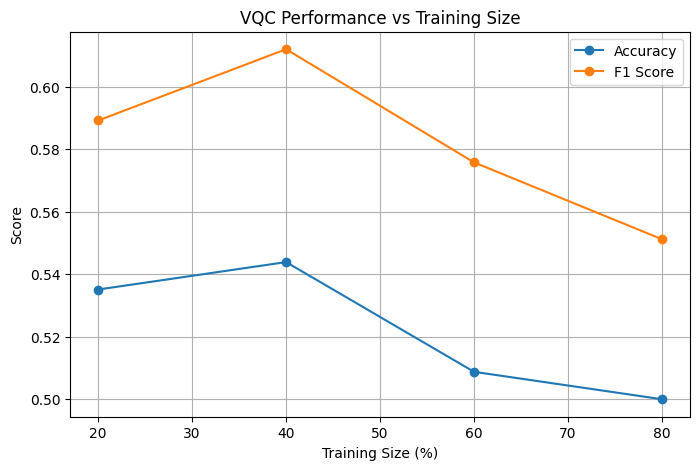

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    vqc_results_df["Training Size"],
    vqc_results_df["Accuracy"],
    marker="o",
    label="Accuracy"
)

plt.plot(
    vqc_results_df["Training Size"],
    vqc_results_df["F1 Score"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Training Size (%)")
plt.ylabel("Score")
plt.title("VQC Performance vs Training Size")
plt.legend()
plt.grid(True)
plt.show()

## Quantum Machine Learning Results

The Variational Quantum Classifier (VQC) was evaluated using different training dataset sizes while keeping the test set fixed.

In this experiment, the VQC performance did not consistently improve as the training size increased. The results varied across the four training sizes, with the best performance observed at one of the intermediate training sizes.

These observations are specific to the dataset, preprocessing, model configuration, and training procedure used in this experiment.

## Classical and Quantum Machine Learning Comparison

The classical machine learning models achieved higher test performance than the Variational Quantum Classifier (VQC) in this experiment. Logistic Regression and SVM achieved the highest test scores among the models evaluated, while Random Forest had slightly lower scores.

The VQC performance varied across the four training sizes tested and did not show a consistent improvement as the training size increased.

However, these results should not be interpreted as a direct comparison of classical and quantum models alone. The classical models were trained using the original 30 features, whereas the VQC used only 2 PCA components because of the small number of qubits in the quantum circuit. In addition, the VQC experiments reused the same classifier object across different training sizes.

Therefore, the results reflect the combined effects of the model type, feature representation, preprocessing, and training procedure used in this experiment.

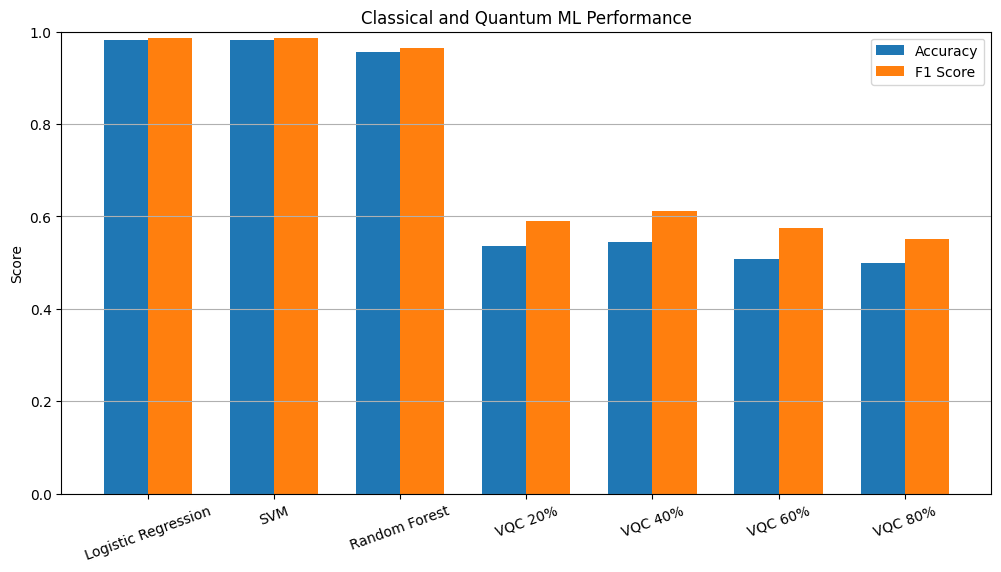

In [ ]:
models = [
    "Logistic Regression",
    "SVM",
    "Random Forest",
    "VQC 20%",
    "VQC 40%",
    "VQC 60%",
    "VQC 80%"
]

accuracy_values = [
    0.982456,
    0.982456,
    0.956140,
    *vqc_results_df["Accuracy"].tolist()
]

f1_values = [
    0.986111,
    0.986111,
    0.965517,
    *vqc_results_df["F1 Score"].tolist()
]
x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(12, 6))

plt.bar(x - width/2, accuracy_values, width, label="Accuracy")
plt.bar(x + width/2, f1_values, width, label="F1 Score")

plt.xticks(x, models, rotation=20)
plt.ylabel("Score")
plt.title("Classical and Quantum ML Performance")
plt.ylim(0, 1)
plt.legend()
plt.grid(axis="y")

plt.show()

## Overall Experimental Observation

The classical machine learning models achieved higher test performance than the VQC in this experiment. Logistic Regression and SVM achieved the highest test performance among the classical models, while Random Forest had slightly lower scores.

The VQC performance varied across the four training sizes tested and did not show a consistent improvement as the training size increased.

However, these results should be interpreted carefully because the classical models used all 30 original features, whereas the VQC used only 2 PCA components. The VQC experiments also reused the same classifier object across training sizes.

Therefore, this experiment demonstrates the practical process of applying a quantum machine learning model to a small dataset and comparing its observed behavior with classical machine learning baselines, rather than establishing a general performance advantage for either approach.

## Limitations

This experiment has several limitations:

1. The classical machine learning models were trained using the original 30 features, while the VQC used only 2 PCA components because the quantum circuit was limited to 2 qubits.

2. The VQC experiments used the same fixed test set, but the training subsets were created by selecting the first 20%, 40%, 60%, and 80% of the training data rather than using repeated random or stratified sampling.

3. The VQC classifier object was reused across the different training sizes. Therefore, the parameters learned in one experiment could influence the following experiment.

4. The experiment was performed using a quantum simulator rather than a physical quantum computer.

5. The results are based on a single train-test split and therefore may vary with a different data split or model configuration.

6. The study uses a small quantum circuit with only 2 qubits and 2 PCA features. Therefore, the results cannot be generalized to larger quantum machine learning models or datasets.

## Conclusion

This project investigated how classical and quantum machine learning methods behave when trained on a small dataset. Three classical machine learning models—Logistic Regression, Support Vector Machine (SVM), and Random Forest—were evaluated and compared with a Variational Quantum Classifier (VQC).

The classical models achieved high test performance on the original 30-feature dataset. The VQC was implemented using a 2-qubit quantum circuit after reducing the feature space to 2 PCA components. Its performance was evaluated using training sizes of 20%, 40%, 60%, and 80%.

In this experiment, increasing the VQC training size did not result in a consistent improvement in performance. The results also showed that the classical and quantum approaches behaved differently under the chosen preprocessing and model configurations.

Overall, the project provided practical experience with classical machine learning, PCA-based dimensionality reduction, quantum feature encoding, variational quantum circuits, and evaluation of machine learning models on a small dataset. The experiment also highlighted the importance of careful experimental design when comparing classical and quantum machine learning methods.